In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')


In [2]:
# =========================
# 1. LOAD DATASET
# =========================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BiLu_ML/paris_housing_prices_dataset_tgs6.csv')

print("="*60)
print("DATA AWAL")
print("="*60)
print(f"Shape: {df.shape}")
print(df.head())

DATA AWAL
Shape: (1200, 10)
  Property_ID  Arrondissement Property_Type  Size_sqm  Rooms  Floor  \
0      P10000               4     Apartment       117      4      7   
1      P10001               8        Studio        89      3      3   
2      P10002               4     Apartment       164      5      5   
3      P10003               2     Apartment        35      1      5   
4      P10004               7        Studio        73      2      2   

   Year_Built         Condition  Distance_to_Center_km   Price_EUR  
0        1870         Renovated                   2.76  2270802.89  
1        1953              Good                  10.77  1637076.12  
2        1979  Needs Renovation                   3.14  3220782.59  
3        1938               New                   4.72   407781.74  
4        1957               New                   7.96   624879.12  


In [3]:
# =========================
# 2. HANDLING MISSING VALUES
# =========================
print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)
print(f"Missing values sebelum handling:\n{df.isnull().sum()}")

if df.isnull().sum().sum() > 0:
    # Numerik: imputasi dengan MEDIAN
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  - {col}: diisi median = {df[col].median()}")

    # Kategorik: imputasi dengan MODUS
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"  - {col}: diisi modus = {df[col].mode()[0]}")
else:
    print("Tidak ada missing values!")


HANDLING MISSING VALUES
Missing values sebelum handling:
Property_ID              0
Arrondissement           0
Property_Type            0
Size_sqm                 0
Rooms                    0
Floor                    0
Year_Built               0
Condition                0
Distance_to_Center_km    0
Price_EUR                0
dtype: int64
Tidak ada missing values!


In [4]:
# =========================
# 3. HAPUS KOLOM ID
# =========================
df = df.drop('Property_ID', axis=1)



EKSPLORASI DATA (EDA)


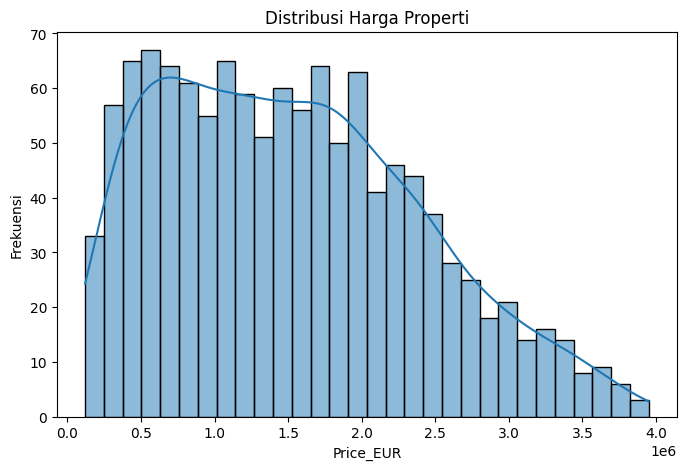

In [6]:
# =========================
# 4. EKSPLORASI DATA (EDA)
# =========================
print("\n" + "="*60)
print("EKSPLORASI DATA (EDA)")
print("="*60)

# Histogram Harga
plt.figure(figsize=(8,5))
sns.histplot(df['Price_EUR'], bins=30, kde=True)
plt.title('Distribusi Harga Properti')
plt.xlabel('Price_EUR')
plt.ylabel('Frekuensi')
plt.show()


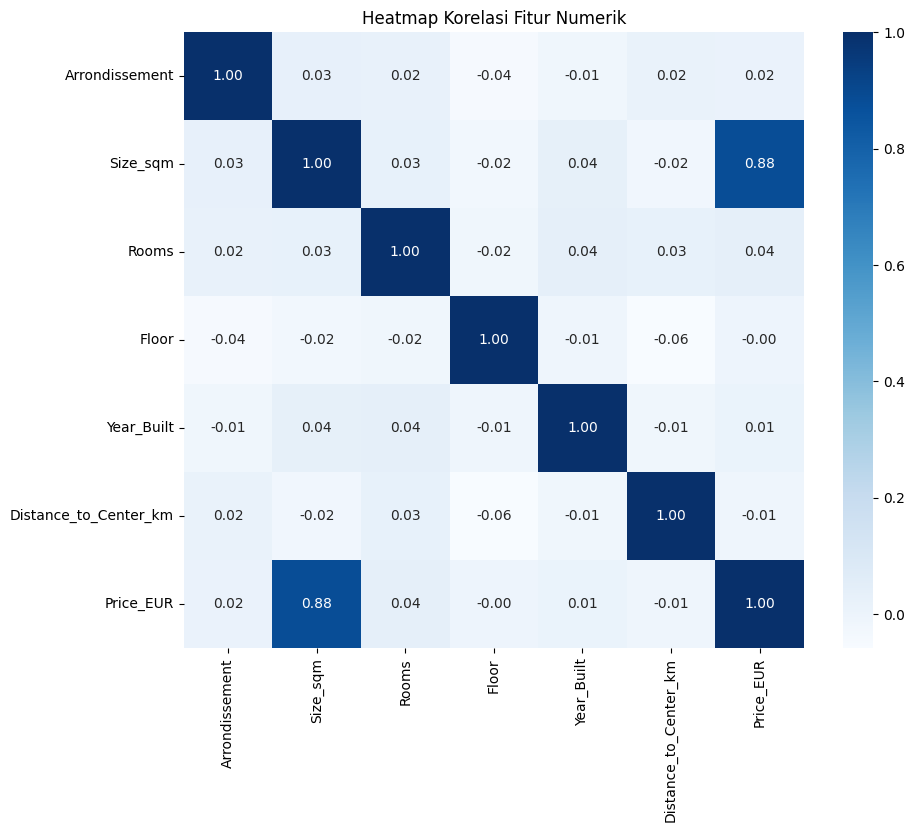

In [7]:
# Heatmap Korelasi
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()


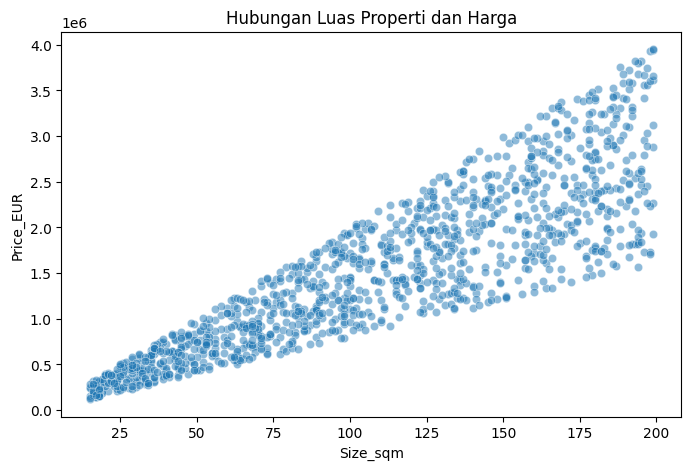

In [8]:
# Scatterplot Size vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Size_sqm'], y=df['Price_EUR'], alpha=0.5)
plt.title('Hubungan Luas Properti dan Harga')
plt.xlabel('Size_sqm')
plt.ylabel('Price_EUR')
plt.show()

In [9]:
# =========================
# 5. PREPROCESSING (Split DULU, baru scaling!)
# =========================
print("\n" + "="*60)
print("PREPROCESSING")
print("="*60)

# Pisahkan fitur dan target
X = df.drop('Price_EUR', axis=1)
y = df['Price_EUR']

# Identifikasi kolom numerik dan kategorik
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Fitur numerik: {numeric_cols}")
print(f"Fitur kategorik: {categorical_cols}")

# SPLIT DATA DULU (SEBELUM preprocessing!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nSplit data:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

# PREPROCESSING dengan MinMaxScaler (sesuai materi!)
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# FIT hanya ke TRAINING data!
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape setelah preprocessing: {X_train_processed.shape}")



PREPROCESSING
Fitur numerik: ['Arrondissement', 'Size_sqm', 'Rooms', 'Floor', 'Year_Built', 'Distance_to_Center_km']
Fitur kategorik: ['Property_Type', 'Condition']

Split data:
  Training: 960 samples
  Testing: 240 samples
Shape setelah preprocessing: (960, 12)


In [11]:
# =========================
# 6. PEMBANGUNAN MODEL (dengan batasan overfitting)
# =========================

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_test_processed)

# Model 2: Decision Tree (dengan batasan cegah overfitting)
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5
)
dt.fit(X_train_processed, y_train)
y_pred_dt = dt.predict(X_test_processed)

# Model 3: Random Forest (dengan batasan cegah overfitting)
rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)

In [12]:
# =========================
# 7. EVALUASI MODEL
# =========================
print("\n" + "="*60)
print("EVALUASI MODEL")
print("="*60)

def hitung_standar_error(y_aktual, y_pred, n, p):
    """Menghitung standar error estimasi (Sy/x) sesuai materi"""
    residuals = y_aktual - y_pred
    ss_res = np.sum(residuals ** 2)
    standar_error = np.sqrt(ss_res / (n - p - 1))
    return standar_error

def evaluasi(nama, y_test, y_pred, X_test):
    n = len(y_test)
    p = X_test.shape[1]

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    standar_error = hitung_standar_error(y_test, y_pred, n, p)

    print(f"\n{'='*40}")
    print(f"Model: {nama}")
    print(f"{'='*40}")
    print(f"MAE  : {mae:,.2f} EUR")
    print(f"MSE  : {mse:,.2f}")
    print(f"RMSE : {rmse:,.2f} EUR")
    print(f"R²   : {r2:.4f}")
    print(f"Standar Error (Sy/x): {standar_error:,.2f} EUR")

    # Interpretasi R² (sesuai materi)
    print(f"\nInterpretasi R² = {r2:.4f}")
    print(f"  → {r2*100:.2f}% variasi harga rumah dapat dijelaskan oleh model")
    print(f"  → {(1-r2)*100:.2f}% dijelaskan faktor lain di luar model")

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'StandarError': standar_error}

# Evaluasi semua model
hasil_lr = evaluasi("Linear Regression", y_test, y_pred_lr, X_test_processed)
hasil_dt = evaluasi("Decision Tree", y_test, y_pred_dt, X_test_processed)
hasil_rf = evaluasi("Random Forest", y_test, y_pred_rf, X_test_processed)



EVALUASI MODEL

Model: Linear Regression
MAE  : 324,703.93 EUR
MSE  : 171,018,690,594.86
RMSE : 413,544.06 EUR
R²   : 0.7790
Standar Error (Sy/x): 425,220.78 EUR

Interpretasi R² = 0.7790
  → 77.90% variasi harga rumah dapat dijelaskan oleh model
  → 22.10% dijelaskan faktor lain di luar model

Model: Decision Tree
MAE  : 362,572.34 EUR
MSE  : 231,698,477,720.79
RMSE : 481,350.68 EUR
R²   : 0.7006
Standar Error (Sy/x): 494,941.97 EUR

Interpretasi R² = 0.7006
  → 70.06% variasi harga rumah dapat dijelaskan oleh model
  → 29.94% dijelaskan faktor lain di luar model

Model: Random Forest
MAE  : 334,783.61 EUR
MSE  : 183,504,862,843.49
RMSE : 428,374.68 EUR
R²   : 0.7628
Standar Error (Sy/x): 440,470.15 EUR

Interpretasi R² = 0.7628
  → 76.28% variasi harga rumah dapat dijelaskan oleh model
  → 23.72% dijelaskan faktor lain di luar model


In [13]:
# =========================
# 8. HYPERPARAMETER TUNING (lebih lengkap!)
# =========================
print("\n" + "="*60)
print("HYPERPARAMETER TUNING (Random Forest)")
print("="*60)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

print(f"\nBest Parameters: {grid.best_params_}")
print(f"Best CV R²: {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test_processed)

print("\n" + "="*40)
print("Random Forest (SETELAH TUNING)")
print("="*40)
print(f"MAE  : {mean_absolute_error(y_test, y_pred_best):,.2f} EUR")
print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")


HYPERPARAMETER TUNING (Random Forest)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV R²: 0.7588

Random Forest (SETELAH TUNING)
MAE  : 331,841.53 EUR
R²   : 0.7689


In [14]:
# =========================
# 9. PERBANDINGAN MODEL
# =========================
print("\n" + "="*60)
print("PERBANDINGAN SEMUA MODEL")
print("="*60)

hasil_compare = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Random Forest (Tuned)'],
    'R² Score': [
        hasil_lr['R2'],
        hasil_dt['R2'],
        hasil_rf['R2'],
        r2_score(y_test, y_pred_best)
    ],
    'MAE (EUR)': [
        hasil_lr['MAE'],
        hasil_dt['MAE'],
        hasil_rf['MAE'],
        mean_absolute_error(y_test, y_pred_best)
    ],
    'Standar Error (EUR)': [
        hasil_lr['StandarError'],
        hasil_dt['StandarError'],
        hasil_rf['StandarError'],
        hitung_standar_error(y_test, y_pred_best, len(y_test), X_test_processed.shape[1])
    ]
})

print(hasil_compare.to_string(index=False))



PERBANDINGAN SEMUA MODEL
                Model  R² Score     MAE (EUR)  Standar Error (EUR)
    Linear Regression  0.778981 324703.928540        425220.780916
        Decision Tree  0.700561 362572.342464        494941.969869
        Random Forest  0.762844 334783.605883        440470.148710
Random Forest (Tuned)  0.768900 331841.527050        434810.509644


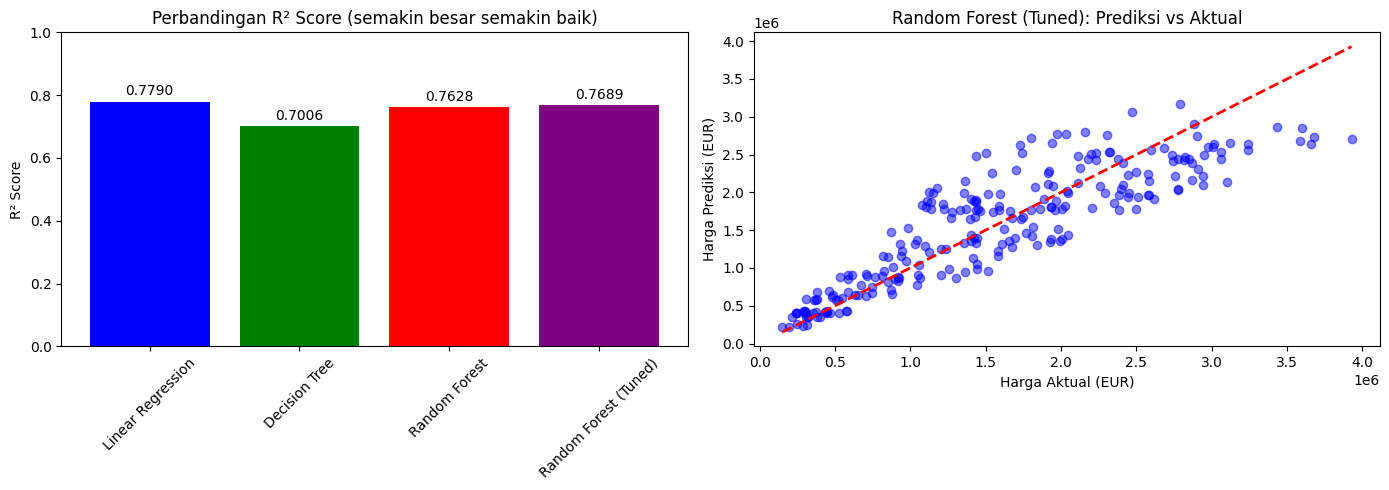

In [15]:
# =========================
# 10. VISUALISASI HASIL
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Bar chart perbandingan R²
bars = axes[0].bar(hasil_compare['Model'], hasil_compare['R² Score'],
                   color=['blue', 'green', 'red', 'purple'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Perbandingan R² Score (semakin besar semakin baik)')
axes[0].tick_params(axis='x', rotation=45)
for bar, r2 in zip(bars, hasil_compare['R² Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{r2:.4f}', ha='center')

# Prediksi vs Aktual (model terbaik - Random Forest Tuned)
axes[1].scatter(y_test, y_pred_best, alpha=0.5, color='blue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Harga Aktual (EUR)')
axes[1].set_ylabel('Harga Prediksi (EUR)')
axes[1].set_title('Random Forest (Tuned): Prediksi vs Aktual')

plt.tight_layout()
plt.show()

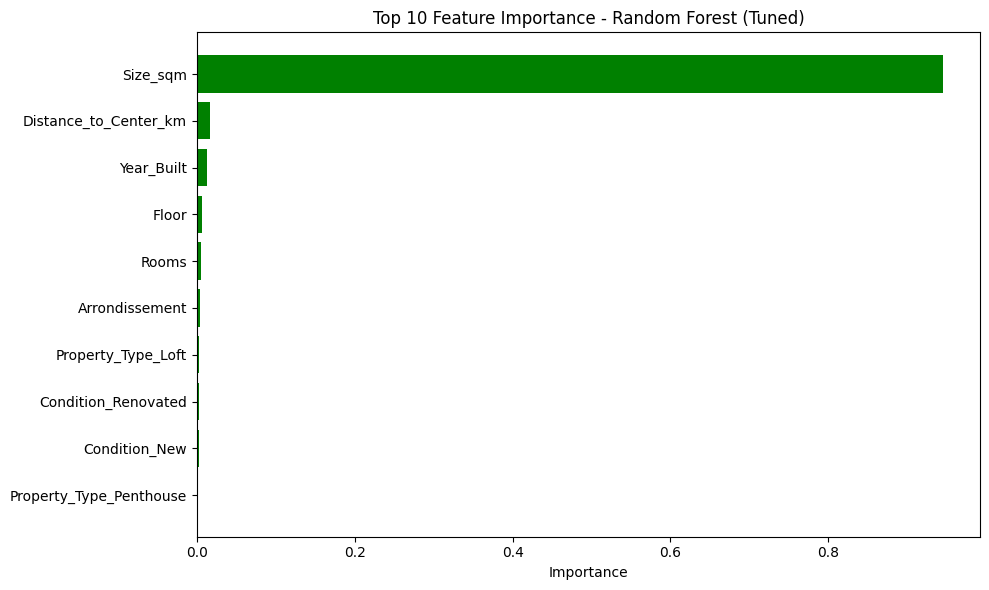

In [16]:
# =========================
# 11. FEATURE IMPORTANCE
# =========================
# Dapatkan nama fitur setelah preprocessing
try:
    feature_names_processed = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    all_features = list(numeric_cols) + list(feature_names_processed)
except:
    all_features = [f"Fitur_{i}" for i in range(X_train_processed.shape[1])]

importance = best_rf.feature_importances_

# Top 10 fitur terpenting
top_idx = np.argsort(importance)[-10:]
top_features = [all_features[i] for i in top_idx]
top_importance = importance[top_idx]

plt.figure(figsize=(10,6))
plt.barh(top_features, top_importance, color='green')
plt.title('Top 10 Feature Importance - Random Forest (Tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [17]:
# =========================
# 12. KESIMPULAN AKHIR
# =========================
print("\n" + "="*60)
print("KESIMPULAN AKHIR")
print("="*60)
print(f"1. Dataset: {df.shape[0]} sampel, {len(numeric_cols) + len(categorical_cols)} fitur awal")
print("2. Handling missing values: Imputasi median (numerik) & modus (kategorik)")
print("3. Normalisasi: MinMaxScaler (sesuai materi dengan rumus X_norm = (X - X_min)/(X_max - X_min))")
print("4. Split data DULU sebelum preprocessing (menghindari data leakage)")
print("5. Overfitting dicegah dengan parameter max_depth, min_samples_split, min_samples_leaf")
print(f"6. Model terbaik: Random Forest (Tuned)")
print(f"7. Performa terbaik: R² = {hasil_compare.loc[3, 'R² Score']:.4f}")
print(f"   → {hasil_compare.loc[3, 'R² Score']*100:.2f}% variasi harga dapat dijelaskan model")
print("8. Standar Error (Sy/x) menunjukkan rata-rata deviasi prediksi dari nilai aktual")
print("\n✅ Kode selesai dijalankan!")


KESIMPULAN AKHIR
1. Dataset: 1200 sampel, 8 fitur awal
2. Handling missing values: Imputasi median (numerik) & modus (kategorik)
3. Normalisasi: MinMaxScaler (sesuai materi dengan rumus X_norm = (X - X_min)/(X_max - X_min))
4. Split data DULU sebelum preprocessing (menghindari data leakage)
5. Overfitting dicegah dengan parameter max_depth, min_samples_split, min_samples_leaf
6. Model terbaik: Random Forest (Tuned)
7. Performa terbaik: R² = 0.7689
   → 76.89% variasi harga dapat dijelaskan model
8. Standar Error (Sy/x) menunjukkan rata-rata deviasi prediksi dari nilai aktual

✅ Kode selesai dijalankan!
